# Getting to Know the Data: Trump vs AOC on Twitter/X
## A First Look at How Two Politicians Use Social Media

---

### Why Are We Looking at This Data?

Social media has become one of the most important spaces for political communication in the 21st century. Politicians no longer rely solely on press conferences, television interviews, or party newspapers to reach their audiences. Instead, platforms like Twitter/X allow them to speak directly to millions of people, bypassing traditional media gatekeepers.

In this study, we use a method called **netnography** -- a way of studying online communities and digital culture, much like an anthropologist might study a village or a historian might study a set of primary sources. Instead of letters, speeches, or newspaper archives, our "primary sources" here are tweets: short public messages posted by two prominent American politicians.

We are comparing **Donald Trump** (Republican, former president) and **Alexandria Ocasio-Cortez / AOC** (Democrat, congresswoman) to understand:

- **How** they use social media differently (posting times, formats, styles)
- **What** these differences tell us about their communication strategies
- **Why** this matters for understanding contemporary political culture

Think of this notebook as your first visit to the archive. We are opening the boxes, counting the documents, and getting a feel for what we are working with before we start interpreting.

---

### What This Notebook Covers

1. **Dataset overview** -- How much data do we have? What does it look like?
2. **When do they tweet?** -- Time-of-day, day-of-week, and weekend patterns
3. **What kinds of tweets do they post?** -- Original posts vs. replies vs. retweets
4. **What formats do they use?** -- Text only, photos, videos, etc.
5. **How long are their tweets?** -- Character and word counts
6. **Summary table** -- A side-by-side comparison of key numbers
7. **Key takeaways** -- What we learned from this first look

---

### A Few Terms You Will See

Before we begin, here are some terms that will come up throughout the notebook:

- **Mean (average)**: Add up all the numbers, then divide by how many there are. For example, if three tweets have 10, 20, and 30 likes, the mean is 20.
- **Median (the middle value when you sort all numbers)**: If you line up all the numbers from smallest to largest, the median is the one right in the middle. This is useful because a few extremely popular tweets can make the average misleading.
- **Standard deviation (how spread out the numbers are)**: A bigger number means more variation. If all tweets get about the same number of likes, the standard deviation is low. If some tweets get 100 likes and others get 1 million, it is high.
- **Engagement rate = total interactions / views**: What percentage of people who saw a tweet actually did something with it (liked, retweeted, replied, etc.).
- **Distribution (how the data is spread across different values)**: Think of it like a histogram -- a bar chart showing where most values fall. Are most tweets short, or is there a wide range of lengths?

In [1]:
# --- Setup: imports and configuration ---

import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from utils.data_loader import load_tweets, load_replies
from utils.plot_helpers import (
    setup_style, get_colors, get_user_label,
    comparative_bar, comparative_boxplot, comparative_hist,
    format_large_numbers
)
from config import FIGURE_SIZE, FIGURE_SIZE_SMALL, FIGURE_SIZE_LARGE, RANDOM_SEED

# Apply consistent style
setup_style()
colors = get_colors()
np.random.seed(RANDOM_SEED)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Setup complete.')

Setup complete.


In [2]:
# --- Load data ---

df = load_tweets()
replies_df = load_replies()

print(f"\nTweets shape:  {df.shape}")
print(f"Replies shape: {replies_df.shape}")

Loaded 200 tweets from processed/


Loaded 11403 replies from processed/

Tweets shape:  (200, 42)
Replies shape: (11403, 19)


## 1. What Does Our Dataset Look Like?

Before we analyze anything, we need to take inventory. How many tweets do we have? What time period do they cover? Is any information missing?

Think of this step like a historian opening an archive box for the first time: you count the documents, check for gaps, and note the date range before you start reading.

In [3]:
# --- Dataset overview ---

# Basic shape
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nTotal tweets: {len(df)}")
print(f"Total replies collected: {len(replies_df)}")
print(f"Number of columns (types of information per tweet): {df.shape[1]}")

# Per-user breakdown
print("\n--- Tweets per User ---")
user_counts = df['user'].value_counts()
for user, count in user_counts.items():
    label = get_user_label(user)
    print(f"  {label}: {count} tweets")

# Date range
print("\n--- Time Period Covered ---")
for user in ['trump', 'aoc']:
    user_df = df[df['user'] == user]
    label = get_user_label(user)
    min_date = user_df['created_at'].min()
    max_date = user_df['created_at'].max()
    date_range = (max_date - min_date).days
    print(f"  {label}:")
    print(f"    From: {min_date.strftime('%Y-%m-%d %H:%M')}")
    print(f"    To:   {max_date.strftime('%Y-%m-%d %H:%M')}")
    print(f"    Span: {date_range} days")

# Missing values
print("\n--- Missing Information (top columns) ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_report = missing_report[missing_report['count'] > 0].sort_values('count', ascending=False)
if len(missing_report) > 0:
    print(missing_report.head(10).to_string())
else:
    print("  No missing values found.")

# Data types summary
print("\n--- Column Data Types ---")
print(df.dtypes.value_counts().to_string())

# Key numeric statistics
print("\n--- Basic Numbers for Key Metrics ---")
key_metrics = ['favorite_count', 'retweet_count', 'reply_count', 'view_count',
               'total_engagement', 'engagement_rate']
display(df[key_metrics].describe().round(2))

DATASET OVERVIEW

Total tweets: 200
Total replies collected: 11403
Number of columns (types of information per tweet): 42

--- Tweets per User ---
  AOC (@AOC): 100 tweets
  Trump (@realDonaldTrump): 100 tweets

--- Time Period Covered ---
  Trump (@realDonaldTrump):
    From: 2025-04-01 20:53
    To:   2026-02-03 02:29
    Span: 307 days
  AOC (@AOC):
    From: 2026-01-23 22:46
    To:   2026-02-26 15:32
    Span: 33 days

--- Missing Information (top columns) ---
                    count   pct
hashtags_extracted    197 98.50
image_paths           171 85.50

--- Column Data Types ---
int64                  19
float64                 7
bool                    6
str                     5
category                1
datetime64[us, UTC]     1
category                1
object                  1
category                1

--- Basic Numbers for Key Metrics ---


,favorite_count,retweet_count,reply_count,view_count,total_engagement,engagement_rate
count,200.00,200.00,200.00,200.00,200.00,200.00
mean,"178,478.06","26,480.35","17,601.96","28,575,455.98","231,994.54",473.85
std,"234,706.93","27,800.96","26,258.52","39,223,235.33","299,799.81","2,433.32"
min,0.00,193.00,0.00,0.00,193.00,0.00
25%,0.00,"4,628.50",0.00,327.50,"7,332.50",0.01
50%,"84,716.00","17,398.00","8,032.00","4,306,114.00","112,748.00",0.02
75%,"318,243.00","41,370.00","25,676.00","46,651,766.00","405,181.00",6.79
max,"1,305,554.00","190,264.00","175,348.00","263,732,066.00","1,688,382.00","28,802.50"


### What does this tell us?

The table above gives us a first impression of the scale we are dealing with. Notice the columns: **favorite_count** (likes), **retweet_count** (shares), **reply_count** (responses), **view_count** (how many people saw it), **total_engagement** (all interactions combined), and **engagement_rate** (percentage of viewers who interacted).

Pay attention to how different the **minimum** and **maximum** values are -- some tweets get barely any attention, while others reach millions of people. This wide range is typical of social media: a few posts go viral while most receive more modest attention.

## 2. When Do They Tweet?

When a politician chooses to post is itself a meaningful choice. It signals when they are active, when they think their audience is paying attention, and even how they organize their daily routine.

Think of it this way: if a politician consistently tweets at 6 AM, they might be targeting early risers or the morning news cycle. If they tweet late at night, they might be speaking to a different audience or reacting to events in real time.

Let us look at three time patterns: **day by day** (the overall rhythm), **hour of the day** (morning vs. night), and **day of the week** (weekdays vs. weekends).

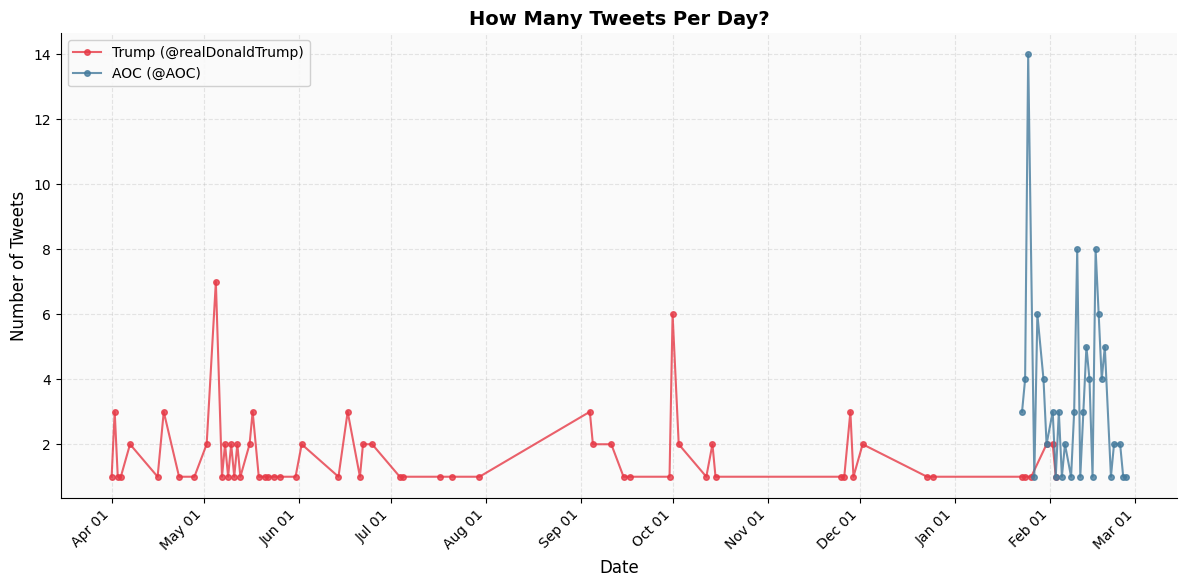

In [4]:
# --- How Many Tweets Per Day? ---

# Aggregate daily tweet counts per user
daily_counts = df.groupby(['date', 'user']).size().reset_index(name='count')
daily_counts['date'] = pd.to_datetime(daily_counts['date'])

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

for user in ['trump', 'aoc']:
    user_data = daily_counts[daily_counts['user'] == user].sort_values('date')
    ax.plot(
        user_data['date'], user_data['count'],
        marker='o', markersize=4, linewidth=1.5, alpha=0.8,
        color=colors[user], label=get_user_label(user)
    )

ax.set_title('How Many Tweets Per Day?', fontweight='bold', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Tweets')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

### What does this tell us?

This chart tracks the daily posting volume for each politician over the time period we collected. The peaks and valleys tell a story: a sudden spike might correspond to a major news event, a political controversy, or a campaign push. A quiet period might mean the politician was traveling, in meetings, or deliberately staying silent.

Compare the two lines: does one politician post more consistently day after day, or are there more dramatic ups and downs? Consistency vs. bursts of activity reflects different communication strategies -- steady presence vs. reactive engagement.

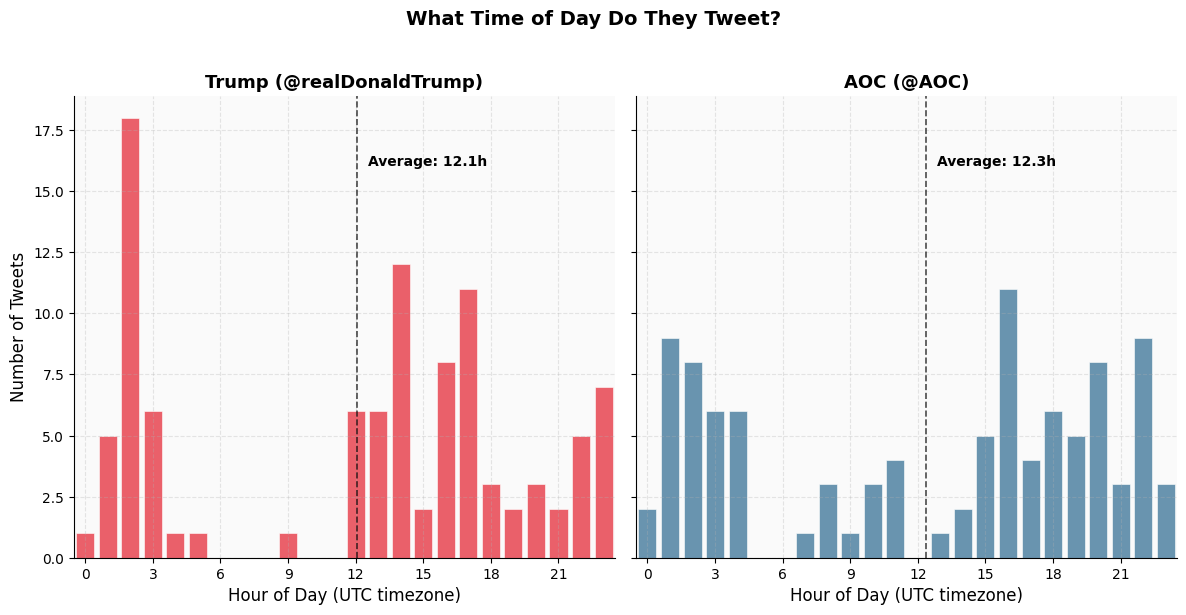

In [5]:
# --- What Time of Day Do They Tweet? ---

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE, sharey=True)

for idx, user in enumerate(['trump', 'aoc']):
    ax = axes[idx]
    user_data = df[df['user'] == user]
    hour_counts = user_data['hour'].value_counts().reindex(range(24), fill_value=0)
    
    ax.bar(
        hour_counts.index, hour_counts.values,
        color=colors[user], alpha=0.8, edgecolor='white', linewidth=0.5
    )
    
    # Mark the average hour
    mean_hour = user_data['hour'].mean()
    ax.axvline(mean_hour, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(
        mean_hour + 0.5, ax.get_ylim()[1] * 0.85,
        f'Average: {mean_hour:.1f}h',
        fontsize=10, fontweight='bold', color='black'
    )
    
    ax.set_title(get_user_label(user), fontweight='bold', fontsize=13)
    ax.set_xlabel('Hour of Day (UTC timezone)')
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlim(-0.5, 23.5)

axes[0].set_ylabel('Number of Tweets')

fig.suptitle('What Time of Day Do They Tweet?', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### What does this tell us?

Each bar represents one hour of the day (in the UTC timezone). The taller the bar, the more tweets were posted during that hour. The dashed line shows the average (mean) posting hour.

Look at the overall shape: is one politician a "morning tweeter" who posts during business hours, while the other is a "night owl" who stays active late? These posting rhythms reflect different audience-targeting strategies. A politician who tweets at midnight may be targeting a national audience across time zones, reacting to breaking news, or simply tweeting based on personal habit. One who concentrates posts during working hours may be more coordinated with a communications team.

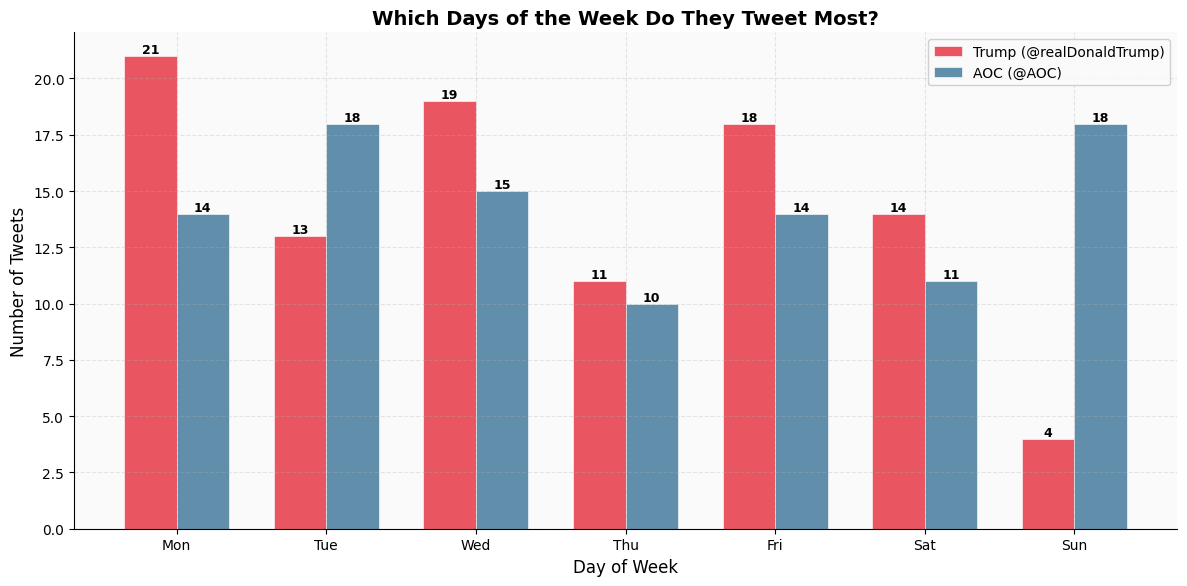

In [6]:
# --- Which Days of the Week Do They Tweet Most? ---

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_abbr = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

x = np.arange(len(day_order))
bar_width = 0.35

for i, user in enumerate(['trump', 'aoc']):
    user_data = df[df['user'] == user]
    day_counts = user_data['day_name'].value_counts().reindex(day_order, fill_value=0)
    offset = -bar_width / 2 + i * bar_width
    bars = ax.bar(
        x + offset, day_counts.values,
        width=bar_width, color=colors[user], alpha=0.85,
        label=get_user_label(user), edgecolor='white', linewidth=0.5
    )
    # Value labels on bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2, height,
                f'{int(height)}', ha='center', va='bottom',
                fontsize=9, fontweight='bold'
            )

ax.set_title('Which Days of the Week Do They Tweet Most?', fontweight='bold', fontsize=14)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Tweets')
ax.set_xticks(x)
ax.set_xticklabels(day_abbr)
ax.legend()
plt.tight_layout()
plt.show()

### What does this tell us?

This chart shows how tweeting activity is spread across the week. Some questions to think about: does one politician take weekends off? Does the other ramp up on certain days? In politics, the rhythm of the week matters -- Monday might bring policy announcements, while Friday evening is traditionally when politicians release news they hope will be ignored (a tactic known as a "Friday news dump").

If one politician tweets consistently every day and the other concentrates on weekdays, it tells us something about whether they treat social media as a personal channel or a professional one.

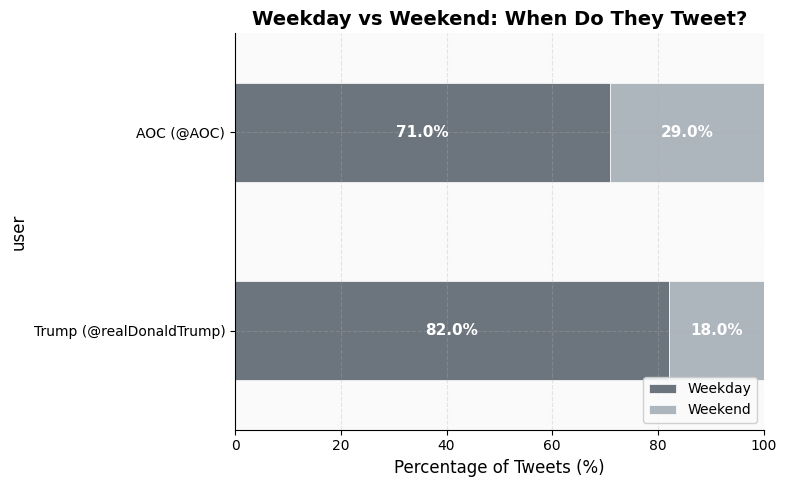

In [7]:
# --- Weekday vs Weekend Tweeting ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)

weekend_data = []
for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]
    total = len(user_data)
    weekday_pct = (user_data['is_weekend'] == False).sum() / total * 100
    weekend_pct = (user_data['is_weekend'] == True).sum() / total * 100
    weekend_data.append({
        'user': get_user_label(user),
        'Weekday': weekday_pct,
        'Weekend': weekend_pct
    })

weekend_df = pd.DataFrame(weekend_data).set_index('user')

# Color mapping for weekday/weekend
bar_colors = ['#6C757D', '#ADB5BD']

weekend_df.plot(
    kind='barh', stacked=True, ax=ax,
    color=bar_colors, edgecolor='white', linewidth=0.5
)

# Add percentage labels on each segment
for idx, (_, row) in enumerate(weekend_df.iterrows()):
    # Weekday label
    ax.text(
        row['Weekday'] / 2, idx,
        f"{row['Weekday']:.1f}%",
        ha='center', va='center', fontsize=11, fontweight='bold', color='white'
    )
    # Weekend label
    ax.text(
        row['Weekday'] + row['Weekend'] / 2, idx,
        f"{row['Weekend']:.1f}%",
        ha='center', va='center', fontsize=11, fontweight='bold', color='white'
    )

ax.set_title('Weekday vs Weekend: When Do They Tweet?', fontweight='bold', fontsize=14)
ax.set_xlabel('Percentage of Tweets (%)')
ax.set_xlim(0, 100)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### What does this tell us?

This chart splits each politician's tweets into weekday vs. weekend posting. If a politician tweets heavily on weekends, it suggests that their social media presence is more personal or "always on." If they concentrate on weekdays, it may indicate a more professional or team-managed approach to social media.

For historians studying political communication, this distinction matters: the boundary between "official" and "personal" communication is one of the defining features of the social media era.

## 3. What Kinds of Tweets Do They Post?

Not all tweets are created equal. On Twitter/X, there are several types:

- **Original tweets**: New posts the politician writes themselves
- **Replies**: Responses to someone else's tweet (a form of conversation)
- **Quotes**: Sharing someone else's tweet with added commentary
- **Retweets**: Simply sharing someone else's tweet without adding anything

The balance between these types reveals a lot about a politician's communication strategy. Someone who mostly posts original tweets is **broadcasting** -- speaking to the public like a megaphone. Someone who frequently replies and quotes is **engaging in conversation** -- participating in a back-and-forth dialogue.

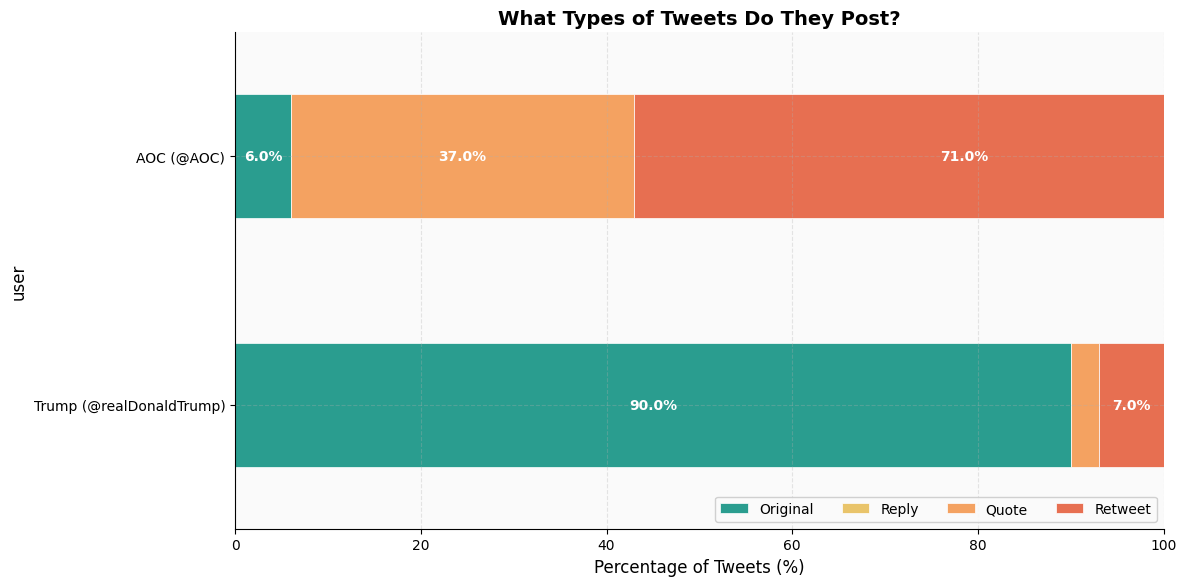


Exact tweet type breakdown:
                          Original  Reply  Quote  Retweet
user                                                     
Trump (@realDonaldTrump)     90.00   0.00   3.00     7.00
AOC (@AOC)                    6.00   0.00  37.00    71.00


In [8]:
# --- What Types of Tweets Do They Post? ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

type_data = []
for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]
    total = len(user_data)
    
    # Classify: retweet > quote > reply > original
    retweet_pct = user_data['is_retweet'].sum() / total * 100
    quote_pct = user_data['is_quote'].sum() / total * 100
    reply_pct = user_data['is_reply'].sum() / total * 100
    # Original = not a retweet, not a quote, and not a reply
    original_pct = ((~user_data['is_retweet']) & (~user_data['is_quote']) & (~user_data['is_reply'])).sum() / total * 100
    
    type_data.append({
        'user': get_user_label(user),
        'Original': original_pct,
        'Reply': reply_pct,
        'Quote': quote_pct,
        'Retweet': retweet_pct
    })

type_df = pd.DataFrame(type_data).set_index('user')

# Color palette for tweet types
type_colors = ['#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']

type_df.plot(
    kind='barh', stacked=True, ax=ax,
    color=type_colors, edgecolor='white', linewidth=0.5
)

# Add percentage labels
for idx, (_, row) in enumerate(type_df.iterrows()):
    cumulative = 0
    for col in type_df.columns:
        value = row[col]
        if value >= 5:  # Only label segments large enough to be readable
            ax.text(
                cumulative + value / 2, idx,
                f'{value:.1f}%',
                ha='center', va='center', fontsize=10, fontweight='bold', color='white'
            )
        cumulative += value

ax.set_title('What Types of Tweets Do They Post?', fontweight='bold', fontsize=14)
ax.set_xlabel('Percentage of Tweets (%)')
ax.set_xlim(0, 100)
ax.legend(loc='lower right', ncol=4)
plt.tight_layout()
plt.show()

# Print exact numbers
print("\nExact tweet type breakdown:")
print(type_df.round(1).to_string())

### What does this tell us?

This stacked bar chart shows the proportion of each tweet type for Trump and AOC. Compare the green (Original) segments: a larger share of originals means the politician is primarily creating their own content, acting as a broadcaster. A larger share of Replies or Quotes suggests a more conversational, dialogic approach.

In the history of political communication, this is a significant shift. Traditional media (newspapers, TV ads, press releases) was almost entirely one-directional. Social media introduces the possibility of dialogue, but not all politicians choose to use it that way. The ratio of originals to replies tells us whether each politician sees Twitter as a **megaphone** or a **town hall**.

## 4. What Formats Do They Use? (Photos, Videos, or Just Text?)

Beyond the type of tweet, the **format** matters too. A tweet can be:
- **Text only** ("none") -- just words
- **Photo** -- includes one or more images
- **Video** -- includes a video clip
- **Mixed** -- a combination of media types

Media choices shape how audiences experience the message. A photo can capture attention instantly, while a text-only tweet relies entirely on the strength of the words.

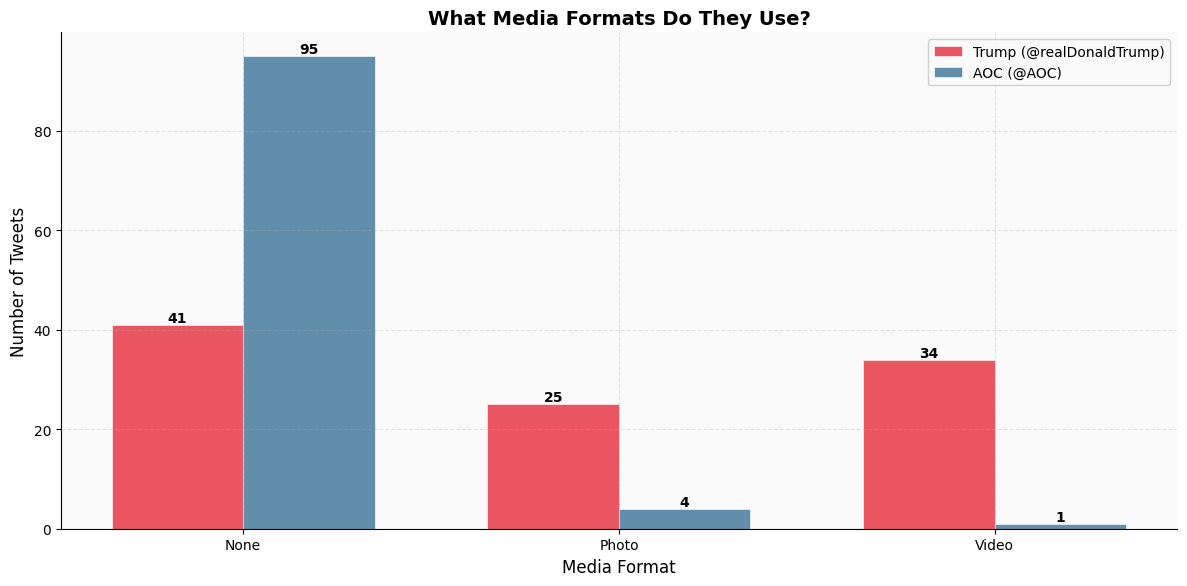

In [9]:
# --- What Media Formats Do They Use? ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

# Get unique media types across both users
media_types = df['media_type'].cat.categories.tolist() if hasattr(df['media_type'], 'cat') else df['media_type'].unique().tolist()
media_types = sorted([mt for mt in media_types if pd.notna(mt)])

x = np.arange(len(media_types))
bar_width = 0.35

for i, user in enumerate(['trump', 'aoc']):
    user_data = df[df['user'] == user]
    counts = user_data['media_type'].value_counts().reindex(media_types, fill_value=0)
    offset = -bar_width / 2 + i * bar_width
    bars = ax.bar(
        x + offset, counts.values,
        width=bar_width, color=colors[user], alpha=0.85,
        label=get_user_label(user), edgecolor='white', linewidth=0.5
    )
    # Value labels
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2, height,
                f'{int(height)}', ha='center', va='bottom',
                fontsize=10, fontweight='bold'
            )

ax.set_title('What Media Formats Do They Use?', fontweight='bold', fontsize=14)
ax.set_xlabel('Media Format')
ax.set_ylabel('Number of Tweets')
ax.set_xticks(x)
ax.set_xticklabels([mt.title() for mt in media_types])
ax.legend()
plt.tight_layout()
plt.show()

### What does this tell us?

This chart compares how often each politician uses text-only tweets, photos, videos, or mixed media. If one politician relies heavily on video while the other sticks to text, it suggests different approaches to digital storytelling.

Visual media (photos and videos) tends to attract more attention on social media platforms because it stops people from scrolling past. Politicians who use more visual content may be making a deliberate choice to prioritize attention-grabbing over detailed policy discussion.

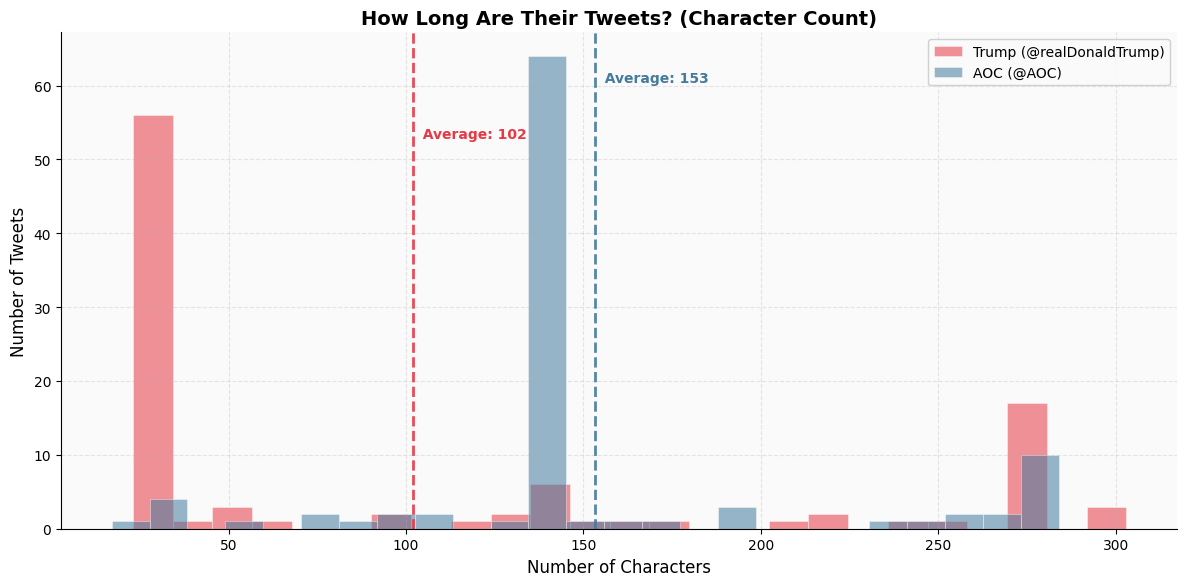

Tweet length statistics (in characters):
       count   mean    std   min    25%    50%    75%    max
user                                                        
aoc   100.00 153.30  59.50 17.00 140.00 140.00 144.00 284.00
trump 100.00 102.00 105.50 23.00  23.00  23.00 178.80 303.00


In [10]:
# --- How Long Are Their Tweets? (Character Count) ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]['text_length'].dropna()
    ax.hist(
        user_data, bins=25, alpha=0.55,
        color=colors[user], edgecolor='white', linewidth=0.5,
        label=get_user_label(user)
    )
    # Average vertical line
    mean_val = user_data.mean()
    ax.axvline(
        mean_val, color=colors[user], linestyle='--', linewidth=2, alpha=0.9
    )
    ax.text(
        mean_val, ax.get_ylim()[1] * 0.9,
        f'  Average: {mean_val:.0f}',
        color=colors[user], fontsize=10, fontweight='bold'
    )

ax.set_title('How Long Are Their Tweets? (Character Count)', fontweight='bold', fontsize=14)
ax.set_xlabel('Number of Characters')
ax.set_ylabel('Number of Tweets')
ax.legend()
plt.tight_layout()
plt.show()

# Summary stats
print("Tweet length statistics (in characters):")
print(df.groupby('user')['text_length'].describe().round(1).to_string())

### What does this tell us?

This chart shows how the tweet lengths are spread out for each politician. The dashed lines show the average (mean) length. If the bars are clustered together on the left, it means most tweets are short. If they spread across the full range, it means the politician uses both short punchy statements and longer, more detailed posts.

In political communication, brevity has always been powerful -- think of slogans like "Yes We Can" or "Make America Great Again." But social media also allows for longer threads and explanations. The balance between short and long tweets reveals whether a politician favors soundbites or substance.

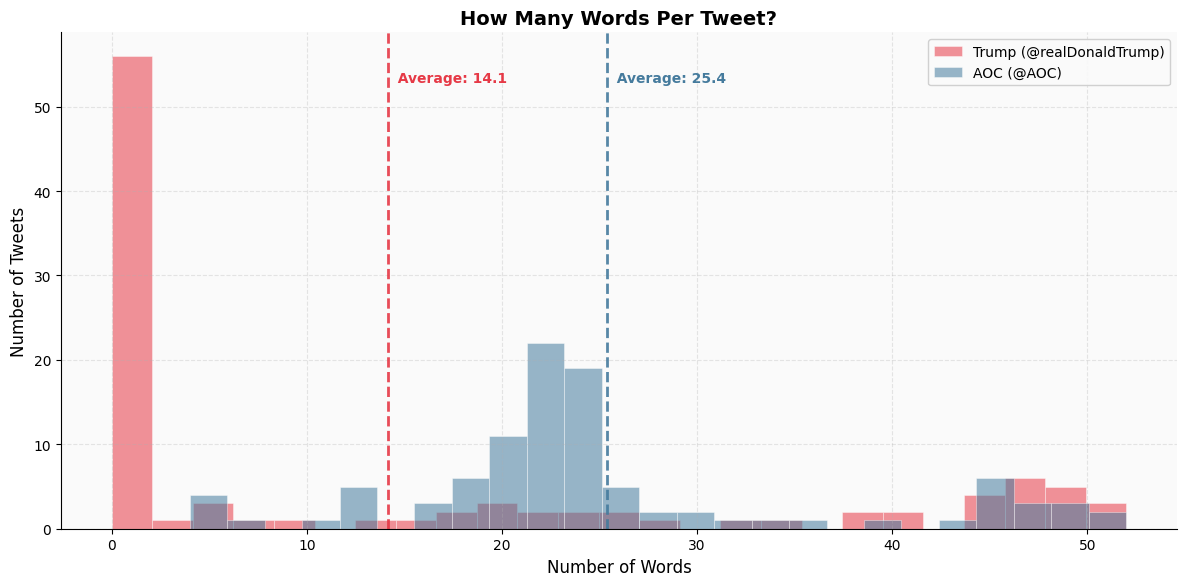

Word count statistics:
       count  mean   std  min   25%   50%   75%   max
user                                                 
aoc   100.00 25.40 11.00 4.00 20.00 23.00 26.20 52.00
trump 100.00 14.10 19.00 0.00  0.00  0.00 27.50 52.00


In [11]:
# --- How Many Words Per Tweet? ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]['word_count'].dropna()
    ax.hist(
        user_data, bins=25, alpha=0.55,
        color=colors[user], edgecolor='white', linewidth=0.5,
        label=get_user_label(user)
    )
    # Average vertical line
    mean_val = user_data.mean()
    ax.axvline(
        mean_val, color=colors[user], linestyle='--', linewidth=2, alpha=0.9
    )
    ax.text(
        mean_val, ax.get_ylim()[1] * 0.9,
        f'  Average: {mean_val:.1f}',
        color=colors[user], fontsize=10, fontweight='bold'
    )

ax.set_title('How Many Words Per Tweet?', fontweight='bold', fontsize=14)
ax.set_xlabel('Number of Words')
ax.set_ylabel('Number of Tweets')
ax.legend()
plt.tight_layout()
plt.show()

# Summary stats
print("Word count statistics:")
print(df.groupby('user')['word_count'].describe().round(1).to_string())

### What does this tell us?

Similar to character count, the word count chart shows us the verbal density of each politician's tweets. Fewer words per tweet means punchier, more slogan-like communication. More words may mean the politician is explaining policy positions, telling stories, or engaging in more complex arguments.

Notice whether the two distributions overlap a lot or barely at all. If they are very different, it confirms that these two politicians have distinctly different rhetorical styles on social media.

## 5. Side-by-Side Comparison: The Numbers at a Glance

The table below puts all the key numbers side by side so you can compare Trump and AOC directly. For each metric, you will see:

- **Mean (average)**: The typical value across all tweets
- **Median (middle value)**: The value right in the center -- useful when a few extreme tweets pull the average up or down
- **Std (standard deviation -- how spread out the numbers are)**: A bigger number means more variation between tweets

In [12]:
# --- Side-by-Side Comparison Table ---

metrics = [
    'text_length', 'word_count', 'favorite_count', 'retweet_count',
    'reply_count', 'view_count', 'engagement_rate', 'hashtag_count', 'media_count'
]

metric_labels = {
    'text_length': 'Tweet Length (characters)',
    'word_count': 'Word Count',
    'favorite_count': 'Likes',
    'retweet_count': 'Retweets (shares)',
    'reply_count': 'Replies',
    'view_count': 'Views',
    'engagement_rate': 'Engagement Rate (% of viewers who interacted)',
    'hashtag_count': 'Hashtags Used',
    'media_count': 'Media Items (photos/videos)'
}

summary_rows = []

for metric in metrics:
    row = {'Metric': metric_labels.get(metric, metric)}
    for user in ['trump', 'aoc']:
        user_data = df[df['user'] == user][metric].dropna()
        label = 'Trump' if user == 'trump' else 'AOC'
        row[f'{label} Average'] = user_data.mean()
        row[f'{label} Middle Value'] = user_data.median()
        row[f'{label} Spread'] = user_data.std()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Metric')

# Style the table
def style_summary(styler):
    """Apply styling to the summary table."""
    styler.format({
        'Trump Average': '{:,.1f}',
        'Trump Middle Value': '{:,.1f}',
        'Trump Spread': '{:,.1f}',
        'AOC Average': '{:,.1f}',
        'AOC Middle Value': '{:,.1f}',
        'AOC Spread': '{:,.1f}',
    })
    styler.set_caption('Side-by-Side Comparison: Trump vs AOC')
    styler.set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'right')]},
    ])
    # Highlight Trump columns in red tint, AOC in blue tint
    trump_cols = [c for c in summary_df.columns if c.startswith('Trump')]
    aoc_cols = [c for c in summary_df.columns if c.startswith('AOC')]
    styler.set_properties(subset=trump_cols, **{'background-color': '#fce4e4'})
    styler.set_properties(subset=aoc_cols, **{'background-color': '#e4ecf4'})
    return styler

display(summary_df.style.pipe(style_summary))

# Also print plain text version
print("\nPlain text version:")
print(summary_df.round(1).to_string())

,Trump Average,Trump Middle Value,Trump Spread,AOC Average,AOC Middle Value,AOC Spread
Metric,,,,,,
Tweet Length (characters),102.0,23.0,105.5,153.3,140.0,59.5
Word Count,14.1,0.0,19.0,25.4,23.0,11.0
Likes,"336,963.4","318,363.0","240,516.8","19,992.7",0.0,"46,261.6"
Retweets (shares),"45,076.1","40,854.5","27,550.8","7,884.6","4,630.5","9,795.7"
Replies,"33,032.8","24,303.5","29,559.8","2,171.1",0.0,"5,583.0"
Views,"56,370,009.9","46,802,237.0","39,099,407.6","780,902.0",332.5,"1,737,657.0"
Engagement Rate (% of viewers who interacted),1.2,0.0,4.7,946.5,2.4,"3,383.9"
Hashtags Used,0.0,0.0,0.1,0.0,0.0,0.1
Media Items (photos/videos),0.6,1.0,0.6,0.1,0.0,0.4



Plain text version:
                                               Trump Average  Trump Middle Value  Trump Spread  AOC Average  AOC Middle Value   AOC Spread
Metric                                                                                                                                    
Tweet Length (characters)                             102.00               23.00        105.50       153.30            140.00        59.50
Word Count                                             14.10                0.00         19.00        25.40             23.00        11.00
Likes                                             336,963.40          318,363.00    240,516.80    19,992.70              0.00    46,261.60
Retweets (shares)                                  45,076.10           40,854.50     27,550.80     7,884.60          4,630.50     9,795.70
Replies                                            33,032.80           24,303.50     29,559.80     2,171.10              0.00     5,583.00
Views 

### What does this tell us?

This table is your "cheat sheet" for comparing the two politicians. A few things to look for:

- **Views**: Which politician reaches more people per tweet? This reflects their overall audience size and platform visibility.
- **Likes vs. Retweets**: Likes are a quick, low-effort form of approval. Retweets require the viewer to actively share the content. A high retweet-to-like ratio suggests content that people want to spread, not just acknowledge.
- **Engagement Rate**: This is perhaps the most revealing number. Even if one politician gets more total views, the other might have a higher engagement rate -- meaning their audience is more actively involved.
- **Spread (standard deviation)**: Large spread values mean the politician has a mix of high-performing and low-performing tweets. Small spread means more consistency.

## 6. Key Takeaways: What We Learned From This First Look

After exploring the data, here are the main observations from this initial analysis:

- **Two very different digital personas**: Even before looking at the content of their tweets, the structural data reveals that Trump and AOC use Twitter in fundamentally different ways. They differ in posting times, tweet types, media preferences, and tweet length -- suggesting distinct digital communication strategies.

- **Broadcasting vs. conversation**: The tweet type breakdown shows whether each politician primarily broadcasts original messages or engages in dialogue through replies and quotes. This distinction maps onto a classic tension in political communication between top-down messaging and participatory engagement.

- **Different daily rhythms**: The hour-of-day and day-of-week charts reveal distinct posting patterns. These rhythms reflect not just personal habits but strategic choices about when to reach audiences. A politician who posts at peak hours is competing for attention; one who posts off-peak may be targeting a dedicated following that checks their feed at all hours.

- **Media format choices reflect communication style**: The balance between text-only posts and visual media (photos, videos) tells us about each politician's approach to digital storytelling. Visual content tends to perform better on algorithmic feeds, so a preference for media-rich posts may indicate platform-savvy communication.

- **Tweet length as rhetorical strategy**: The character and word count distributions show whether each politician favors short, punchy statements (closer to slogans) or longer, more elaborate posts (closer to essays or policy explanations). This has implications for how their messages are consumed and shared.

- **Scale of audience**: The raw view counts and engagement numbers reveal the enormous scale of these politicians' digital reach. Even within our sample of 100 tweets each, we are looking at millions of views and hundreds of thousands of interactions -- numbers that rival traditional media audiences.

- **Consistency vs. variability**: The spread (standard deviation) in engagement metrics tells us whether a politician gets consistently similar responses or whether they have dramatic hits and misses. High variability suggests that some content resonates much more strongly than others, which is worth investigating further.

### What Comes Next

This notebook gave us the lay of the land. In the next notebooks, we will dig deeper:

- **Notebook 2**: Who gets more attention? A detailed look at engagement (likes, retweets, replies) and what drives it
- **Notebook 3**: What do they actually say? Content and language analysis
- **Notebook 4**: Who talks to whom? Network and interaction patterns
- **Notebook 5**: Bringing it all together -- a comparative portrait of digital political communication

---

*Note: This study treats social media posts as cultural artifacts -- primary sources for understanding contemporary political communication. The 100-tweet sample per politician provides a snapshot of recent digital behavior, much like a historian might analyze a selection of letters or speeches to understand a political figure's public persona.*